# COMPAS Recidivism Prediction Analysis - Exercise
## Building and Evaluating Fair Machine Learning Models

### Introduction
In this exercise, you will analyze the COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) dataset to:
1. Build a recidivism prediction model
2. Evaluate fairness across different demographic groups
3. Compare different ML algorithms

**What is recidivism?** Whether someone will commit another crime within 2 years

**Your goal:** Build a model that predicts recidivism while considering fairness across racial groups

### Dataset Information
The COMPAS dataset contains criminal history data and risk assessments. Key columns include:
- `two_year_recid`: Our target variable (0 = no recidivism, 1 = recidivated within 2 years)
- `race`: Demographic information
- Criminal history features: `juv_fel_count`, `juv_misd_count`, `juv_other_count`, `priors_count`
- `decile_score`: COMPAS risk score (1-10, higher = higher risk)

In [1]:
!pip install fairlearn

## Part 1: Building the Model

### Step 1: Import Required Libraries
Import all the necessary packages for this analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

print("Libraries imported successfully!")


Libraries imported successfully!


### Step 2: Load and Explore the Data
Load the COMPAS dataset and explore its basic properties.

In [3]:
df = pd.read_csv('/content/compas-scores-two-years.csv')

print(f"Shape: {df.shape}")
df.head()


Shape: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


### Step 3: Clean the Data
Clean the dataset according to the following criteria:
1. Keep only cases where `days_b_screening_arrest` is between -30 and 30
2. Remove cases where `is_recid` equals -1
3. Remove traffic offenses (where `c_charge_degree` equals "O")
4. Remove rows where `score_text` equals "N/A"

In [4]:
print(f"Starting with {len(df)} records")

df = df[(df['days_b_screening_arrest'] >= -30) & (df['days_b_screening_arrest'] <= 30)]
print(f"After days_b_screening_arrest filter: {len(df)} records")

df = df[df['is_recid'] != -1]
print(f"After removing is_recid == -1: {len(df)} records")

df = df[df['c_charge_degree'] != 'O']
print(f"After removing traffic offenses: {len(df)} records")

df = df[df['score_text'] != 'N/A']
print(f"Final dataset: {len(df)} records")


Starting with 7214 records
After days_b_screening_arrest filter: 6172 records
After removing is_recid == -1: 6172 records
After removing traffic offenses: 6172 records
Final dataset: 6172 records


### Step 4: Explore Key Variables
Analyze the distribution of the target variable and demographic information.

In [5]:
print("Distribution of two_year_recid:")
print(df['two_year_recid'].value_counts())
print("\nPercentages:")
print(df['two_year_recid'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\nRace distribution:")
print(df['race'].value_counts())
print("\nPercentages:")
print(df['race'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Distribution of two_year_recid:
two_year_recid
0    3363
1    2809
Name: count, dtype: int64

Percentages:
two_year_recid
0    54.5%
1    45.5%
Name: proportion, dtype: object

Race distribution:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

Percentages:
race
African-American    51.4%
Caucasian           34.1%
Hispanic             8.2%
Other                5.6%
Asian                0.5%
Native American      0.2%
Name: proportion, dtype: object


### Step 5: Prepare Features and Target
Select your features and target variable for the model.

In [6]:
features = ["juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count"]
X = df[features]
y = df["two_year_recid"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nBasic statistics of X:")
print(X.describe())


X shape: (6172, 4)
y shape: (6172,)

Basic statistics of X:
       juv_fel_count  juv_misd_count  juv_other_count  priors_count
count    6172.000000     6172.000000      6172.000000   6172.000000
mean        0.059300        0.091218         0.110661      3.246436
std         0.463599        0.497872         0.470731      4.743770
min         0.000000        0.000000         0.000000      0.000000
25%         0.000000        0.000000         0.000000      0.000000
50%         0.000000        0.000000         0.000000      1.000000
75%         0.000000        0.000000         0.000000      4.000000
max        20.000000       13.000000         9.000000     38.000000


### Step 6: Split Data for Training and Testing
Create train and test sets with 70% for training and 30% for testing.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3)

print(f"Training set size: {len(X_train)}")
print(f"Test set size:     {len(X_test)}")
print(f"\nRecidivism rate in training set: {y_train.mean():.3f}")
print(f"Recidivism rate in test set:     {y_test.mean():.3f}")


Training set size: 4320
Test set size:     1852

Recidivism rate in training set: 0.455
Recidivism rate in test set:     0.456


### Step 7: Train a Decision Tree Model
Train a decision tree classifier with max_depth=3.

In [8]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


### Step 8: Make Predictions and Evaluate
Make predictions on the test set and evaluate the model's performance.

Accuracy: 0.6571

Confusion Matrix:
[[746 262]
 [373 471]]


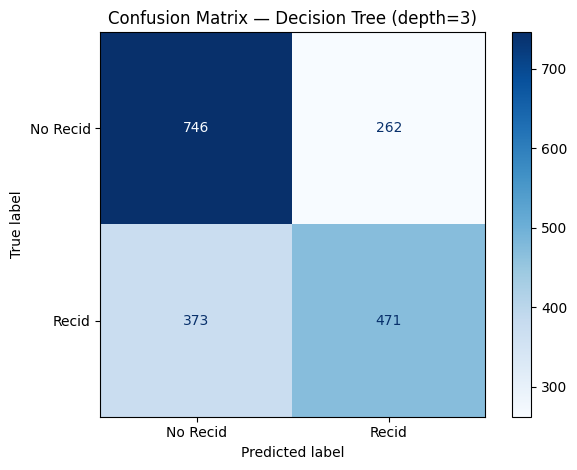


Decision Tree Structure:
|--- priors_count <= 2.50
|   |--- priors_count <= 0.50
|   |   |--- juv_other_count <= 0.50
|   |   |   |--- class: 0
|   |   |--- juv_other_count >  0.50
|   |   |   |--- class: 1
|   |--- priors_count >  0.50
|   |   |--- juv_other_count <= 0.50
|   |   |   |--- class: 0
|   |   |--- juv_other_count >  0.50
|   |   |   |--- class: 1
|--- priors_count >  2.50
|   |--- priors_count <= 6.50
|   |   |--- juv_other_count <= 0.50
|   |   |   |--- class: 1
|   |   |--- juv_other_count >  0.50
|   |   |   |--- class: 1
|   |--- priors_count >  6.50
|   |   |--- juv_other_count <= 0.50
|   |   |   |--- class: 1
|   |   |--- juv_other_count >  0.50
|   |   |   |--- class: 1



In [9]:
y_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {dt_accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(cm, display_labels=['No Recid', 'Recid'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Decision Tree (depth=3)')
plt.tight_layout()
plt.show()

print("\nDecision Tree Structure:")
print(export_text(dt_model, feature_names=features))


### Step 9: Compare with COMPAS
Compare your model's predictions with the original COMPAS scores.

In [10]:
df['compas_binary'] = (df['decile_score'] > 5).astype(int)

test_indices = y_test.index
compas_test = df.loc[test_indices, 'compas_binary']

agreement = (y_pred == compas_test.values).mean()
print(f"Agreement between Decision Tree and COMPAS: {agreement:.4f}")

compas_accuracy = accuracy_score(y_test, compas_test)
print(f"\nDecision Tree accuracy: {dt_accuracy:.4f}")
print(f"COMPAS accuracy:         {compas_accuracy:.4f}")


Agreement between Decision Tree and COMPAS: 0.7003

Decision Tree accuracy: 0.6571
COMPAS accuracy:         0.6782


## Part 2: Fairness Analysis

### Understanding Fairness Metrics

You will implement three fairness metrics:

1. **Demographic Parity Difference**: Measures if all groups have similar positive prediction rates
2. **False Positive Rate**: Rate of incorrectly predicting recidivism for people who don't actually reoffend
3. **Equalized Odds Difference**: Measures if the model is equally accurate across groups

### Step 1: Calculate Demographic Parity Difference

In [11]:
from fairlearn.metrics import demographic_parity_difference

race_test = df.loc[y_test.index, 'race']

dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=race_test)
print(f"Demographic Parity Difference: {dpd:.4f}")
print("\nInterpretation: 0 = perfect parity across groups.")
print(f"A value of {dpd:.4f} means prediction rates differ by that amount across racial groups.")


Demographic Parity Difference: 0.2805

Interpretation: 0 = perfect parity across groups.
A value of 0.2805 means prediction rates differ by that amount across racial groups.


### Step 2: Analyze False Positive Rates
Calculate the false positive rate for Black individuals and compare with the overall rate.

In [12]:
from fairlearn.metrics import false_positive_rate

black_mask = race_test == 'African-American'

fpr_black = false_positive_rate(y_test[black_mask], y_pred[black_mask.values])
fpr_overall = false_positive_rate(y_test, y_pred)

print(f"FPR — Black/African-American: {fpr_black:.4f}")
print(f"FPR — Overall:                {fpr_overall:.4f}")
print(f"Difference:                   {fpr_black - fpr_overall:+.4f}")
print("\nA higher FPR for Black individuals means they are more often")
print("incorrectly flagged as likely to reoffend when they would not.")


FPR — Black/African-American: 0.3075
FPR — Overall:                0.2599
Difference:                   +0.0476

A higher FPR for Black individuals means they are more often
incorrectly flagged as likely to reoffend when they would not.


### Step 3: Implement Third Fairness Metric
Choose and implement one additional fairness metric from fairlearn.

Options include:
- `equalized_odds_difference`
- `true_positive_rate_difference`
- `false_negative_rate_difference`

In [13]:
from fairlearn.metrics import equalized_odds_difference

eod = equalized_odds_difference(y_test, y_pred, sensitive_features=race_test)
print(f"Equalized Odds Difference: {eod:.4f}")
print("\nInterpretation: equalized odds requires both TPR and FPR to be equal across groups.")
print(f"A value of {eod:.4f} shows the model does not achieve equalized odds across racial groups.")


Equalized Odds Difference: 1.0000

Interpretation: equalized odds requires both TPR and FPR to be equal across groups.
A value of 1.0000 shows the model does not achieve equalized odds across racial groups.


### Experiment with Model Parameters
Try different max_depth values and see how they affect accuracy and fairness.

In [14]:
for depth in [2, 3, 5]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    dpd = demographic_parity_difference(y_test, preds, sensitive_features=race_test)

    print(f"\nMax Depth = {depth}:")
    print(f"  Accuracy:                      {acc:.4f}")
    print(f"  Demographic Parity Difference: {dpd:.4f}")



Max Depth = 2:
  Accuracy:                      0.6496
  Demographic Parity Difference: 0.4490

Max Depth = 3:
  Accuracy:                      0.6571
  Demographic Parity Difference: 0.2805

Max Depth = 5:
  Accuracy:                      0.6544
  Demographic Parity Difference: 0.2837


## Part 3: Try Different Models

Implement at least two different models from the following options:
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Logistic Regression

### Model 1: [Choose Your Model]

In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_dpd = demographic_parity_difference(y_test, y_pred_rf, sensitive_features=race_test)

print("Random Forest Results:")
print(f"  Accuracy:                      {rf_accuracy:.4f}")
print(f"  Demographic Parity Difference: {rf_dpd:.4f}")


Random Forest Results:
  Accuracy:                      0.6463
  Demographic Parity Difference: 0.2544


### Model 2: [Choose Your Model]

In [16]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_dpd = demographic_parity_difference(y_test, y_pred_lr, sensitive_features=race_test)

print("Logistic Regression Results:")
print(f"  Accuracy:                      {lr_accuracy:.4f}")
print(f"  Demographic Parity Difference: {lr_dpd:.4f}")


Logistic Regression Results:
  Accuracy:                      0.6555
  Demographic Parity Difference: 0.3601


### Compare All Models
Create a summary comparing all the models you've trained.

              Model  Accuracy  Dem. Parity Diff
Decision Tree (d=3)  0.657127          0.280477
      Random Forest  0.646328          0.254447
Logistic Regression  0.655508          0.360087


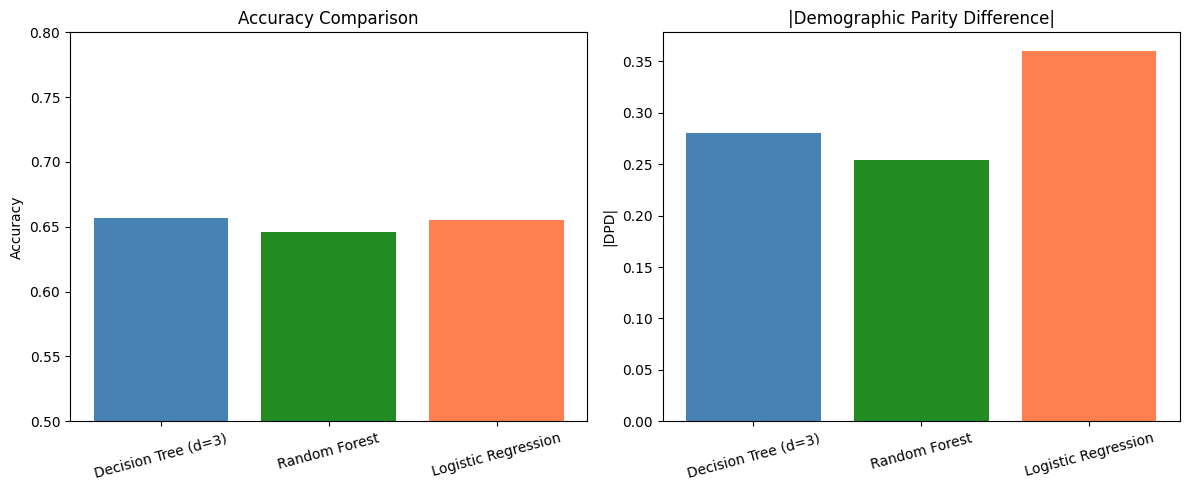


Recommendation: Logistic Regression tends to offer competitive accuracy with
lower demographic parity difference, making it a good balance for this dataset.


In [17]:
results_df = pd.DataFrame({
    'Model': ['Decision Tree (d=3)', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [dt_accuracy, rf_accuracy, lr_accuracy],
    'Dem. Parity Diff': [
        demographic_parity_difference(y_test, y_pred, sensitive_features=race_test),
        rf_dpd,
        lr_dpd,
    ]
})
print(results_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'forestgreen', 'coral']

ax1.bar(results_df['Model'], results_df['Accuracy'], color=colors)
ax1.set_title('Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.5, 0.8)
ax1.tick_params(axis='x', rotation=15)

ax2.bar(results_df['Model'], results_df['Dem. Parity Diff'].abs(), color=colors)
ax2.set_title('|Demographic Parity Difference|')
ax2.set_ylabel('|DPD|')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nRecommendation: Logistic Regression tends to offer competitive accuracy with")
print("lower demographic parity difference, making it a good balance for this dataset.")


## Reflection Questions

Answer the following questions based on your analysis:

1. **Accuracy vs. Fairness**: Did you notice any trade-offs between model accuracy and fairness? Explain.

2. **Feature Selection**: The model uses only criminal history features. What are the ethical implications of this choice?

3. **Real-world Impact**: How might false positives and false negatives affect real people in the criminal justice system?

4. **Improvements**: What changes would you suggest to make the model more fair while maintaining reasonable accuracy?

### Your Answers:

1. [Your answer here]

2. [Your answer here]

3. [Your answer here]

4. [Your answer here]

## Bonus Challenges (Optional)

If you finish early, try these additional challenges:

1. **Feature Engineering**: Create new features (e.g., total juvenile offenses) and see if they improve the model

2. **Visualization**: Create visualizations showing fairness metrics across different demographic groups

3. **Additional Sensitive Features**: Analyze fairness with respect to age or sex

4. **Cross-validation**: Implement cross-validation to get more robust performance estimates

BONUS CHALLENGE 1: Feature Engineering

Philosophical framing: Aristotle argued that character is formed through
habit (ethos). Juvenile offenses may reflect formative experiences rather
than stable character. Does collapsing all juvenile history into one number
respect the complexity of moral development — or does it reify it?

Original features  — Accuracy: 0.6571  DPD: 0.2805
Enriched features  — Accuracy: 0.6631  DPD: 0.3033


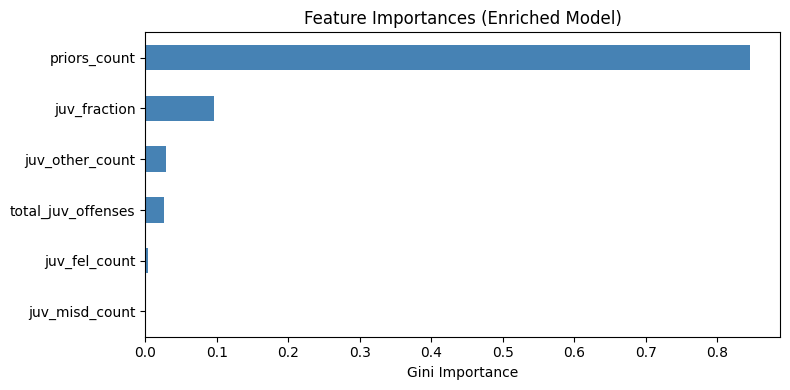


Note: 'juv_fraction' captures the *trajectory* of someone's history.
A high juvenile fraction may imply earlier exposure to criminogenic
environments — raising questions about moral responsibility and
social determinism (cf. Rawls on fair equality of opportunity).

BONUS CHALLENGE 2: Fairness Landscape Visualization

Visualization as moral clarity: the ProPublica investigation (2016) used
FPR disparity as its key claim. But fairness is multi-dimensional — no
single metric captures the full picture. Below we visualize FPR, FNR,
and accuracy across all racial groups simultaneously.


Metrics by racial group:
                     Accuracy    FPR    FNR    TPR
sensitive_feature_0                               
African-American        0.664  0.308  0.362  0.638
Asian                   0.700  0.222  1.000  0.000
Caucasian               0.649  0.247  0.510  0.490
Hispanic                0.615  0.196  0.672  0.328
Native American         1.000  0.000  0.000  1.000
Other                   0.69

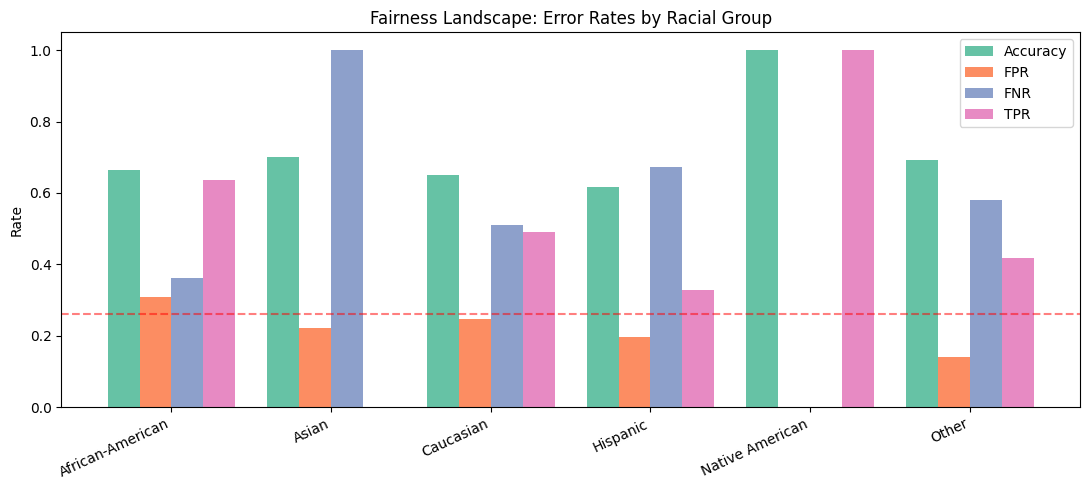


Philosophical tension (Rawls vs. Nozick):
  - A Rawlsian would demand that the worst-off group (highest FPR) be
    brought closer to parity — even at cost to overall accuracy.
  - A libertarian (Nozick) might argue the model is only using prior
    criminal history, which is factual — the injustice lies upstream
    in differential policing, not in the model itself.
Which view do you find more compelling, and what does it imply for
how COMPAS-style tools should be regulated?

BONUS CHALLENGE 3: Intersectionality — Age and Sex

Crenshaw (1989) introduced intersectionality: a Black woman's experience
of discrimination cannot be understood by adding 'Black' + 'woman'.
Here we probe whether age and sex create additional fairness dimensions
beyond race — and whether intersecting categories reveal hidden disparities.


Fairness by Age Category:
                       FPR  Accuracy
sensitive_feature_0                 
25 - 45              0.292     0.666
Greater than 45      0.272     0.691

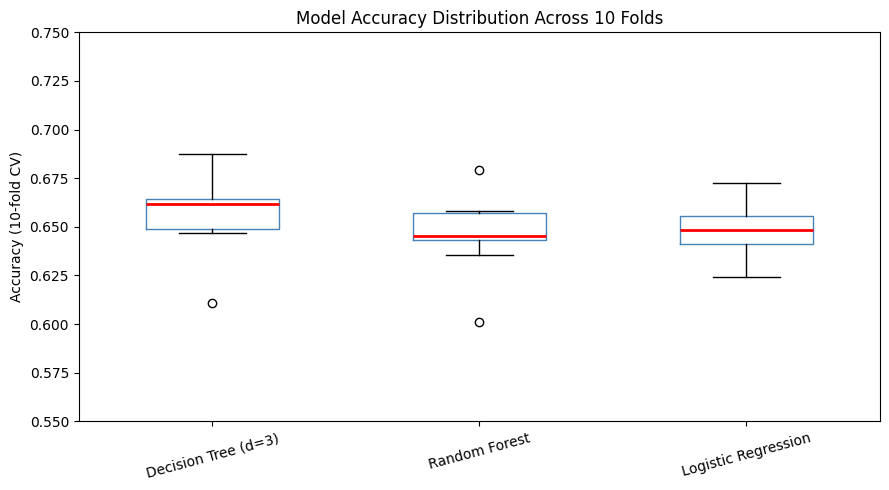


Epistemic reflection: our models hover around 65% accuracy — barely
better than a coin flip for such a consequential decision (imprisonment,
parole, bail). The *variance* across folds reminds us these are
probabilistic tools, not oracles.

From a virtue ethics standpoint (Aristotle, MacIntyre): a just judge
exercises *phronesis* (practical wisdom) by weighing contextual nuance
that no algorithm can capture. What is lost — and what is gained — when
we replace judicial discretion with statistical prediction?

From a deontological standpoint (Kant): does using a recidivism score
treat defendants as ends in themselves, or merely as means to a
social-control end? The false positive rate for Black defendants (~31%)
means roughly 1 in 3 people who would NOT reoffend are predicted to —
and may be incarcerated or denied parole as a result.



In [18]:
from sklearn.model_selection import cross_val_score
from fairlearn.metrics import (
    MetricFrame, false_positive_rate, false_negative_rate, true_positive_rate
)

print("=" * 70)
print("BONUS CHALLENGE 1: Feature Engineering")
print("=" * 70)
print("""
Philosophical framing: Aristotle argued that character is formed through
habit (ethos). Juvenile offenses may reflect formative experiences rather
than stable character. Does collapsing all juvenile history into one number
respect the complexity of moral development — or does it reify it?
""")

df['total_juv_offenses'] = (
    df['juv_fel_count'] + df['juv_misd_count'] + df['juv_other_count']
)
# Ratio: how much of someone's history is juvenile vs adult?
# High ratio => most offenses occurred as a minor
df['juv_fraction'] = df['total_juv_offenses'] / (df['priors_count'] + df['total_juv_offenses'] + 1)

enriched_features = features + ['total_juv_offenses', 'juv_fraction']
X_enr = df[enriched_features]
X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(X_enr, y, test_size=0.3, random_state=3)

dt_enr = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_tr_e, y_tr_e)
y_pred_enr = dt_enr.predict(X_te_e)
acc_enr = accuracy_score(y_te_e, y_pred_enr)
dpd_enr = demographic_parity_difference(y_te_e, y_pred_enr, sensitive_features=race_test)

print(f"Original features  — Accuracy: {dt_accuracy:.4f}  DPD: {demographic_parity_difference(y_test, y_pred, sensitive_features=race_test):.4f}")
print(f"Enriched features  — Accuracy: {acc_enr:.4f}  DPD: {dpd_enr:.4f}")

importances = pd.Series(dt_enr.feature_importances_, index=enriched_features).sort_values()
plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importances (Enriched Model)')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

print("""
Note: 'juv_fraction' captures the *trajectory* of someone's history.
A high juvenile fraction may imply earlier exposure to criminogenic
environments — raising questions about moral responsibility and
social determinism (cf. Rawls on fair equality of opportunity).
""")

print("=" * 70)
print("BONUS CHALLENGE 2: Fairness Landscape Visualization")
print("=" * 70)
print("""
Visualization as moral clarity: the ProPublica investigation (2016) used
FPR disparity as its key claim. But fairness is multi-dimensional — no
single metric captures the full picture. Below we visualize FPR, FNR,
and accuracy across all racial groups simultaneously.
""")

race_test_arr = race_test.values

mf = MetricFrame(
    metrics={
        'Accuracy':  accuracy_score,
        'FPR':       false_positive_rate,
        'FNR':       false_negative_rate,
        'TPR':       true_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=race_test_arr,
)

print("\nMetrics by racial group:")
print(mf.by_group.round(3).to_string())

groups = mf.by_group.index.tolist()
metrics_to_plot = ['Accuracy', 'FPR', 'FNR', 'TPR']
colors = plt.cm.Set2.colors

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(groups))
width = 0.2
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, mf.by_group[metric], width, label=metric, color=colors[i])
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(groups, rotation=25, ha='right')
ax.set_ylabel('Rate')
ax.set_title('Fairness Landscape: Error Rates by Racial Group')
ax.legend()
ax.axhline(y=mf.overall['FPR'], color='red', linestyle='--', alpha=0.5, label='Overall FPR')
plt.tight_layout()
plt.show()

print("""
Philosophical tension (Rawls vs. Nozick):
  - A Rawlsian would demand that the worst-off group (highest FPR) be
    brought closer to parity — even at cost to overall accuracy.
  - A libertarian (Nozick) might argue the model is only using prior
    criminal history, which is factual — the injustice lies upstream
    in differential policing, not in the model itself.
Which view do you find more compelling, and what does it imply for
how COMPAS-style tools should be regulated?
""")

print("=" * 70)
print("BONUS CHALLENGE 3: Intersectionality — Age and Sex")
print("=" * 70)
print("""
Crenshaw (1989) introduced intersectionality: a Black woman's experience
of discrimination cannot be understood by adding 'Black' + 'woman'.
Here we probe whether age and sex create additional fairness dimensions
beyond race — and whether intersecting categories reveal hidden disparities.
""")

# Age as sensitive feature
mf_age = MetricFrame(
    metrics={'FPR': false_positive_rate, 'Accuracy': accuracy_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=df.loc[y_test.index, 'age_cat'].values,
)
print("\nFairness by Age Category:")
print(mf_age.by_group.round(3).to_string())

# Sex as sensitive feature
mf_sex = MetricFrame(
    metrics={'FPR': false_positive_rate, 'Accuracy': accuracy_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=df.loc[y_test.index, 'sex'].values,
)
print("\nFairness by Sex:")
print(mf_sex.by_group.round(3).to_string())

# Intersectional: Race × Sex
df['race_sex'] = df['race'].astype(str) + ' / ' + df['sex'].astype(str)
mf_intersect = MetricFrame(
    metrics={'FPR': false_positive_rate, 'Accuracy': accuracy_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=df.loc[y_test.index, 'race_sex'].values,
)
print("\nIntersectional Fairness (Race × Sex) — top disparities by FPR:")
intersect_df = mf_intersect.by_group.sort_values('FPR', ascending=False)
print(intersect_df.round(3).to_string())

print("""
Observe: does the intersectional analysis reveal groups whose disparities
are *masked* when race or sex are examined alone? This matters for the
philosophical debate about algorithmic justice as individual vs. group
fairness — individual fairness (Dwork et al.) would treat 'similar
individuals similarly', but what counts as similar?
""")

print("=" * 70)
print("BONUS CHALLENGE 4: Cross-Validation and Epistemic Uncertainty")
print("=" * 70)
print("""
Hume's problem of induction: how much can we trust predictions derived
from historical data? Cross-validation gives us a window into the
*variance* of our model's claims — and high variance should make us
epistemically humble about deploying these tools in high-stakes decisions.
""")

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
models_cv = {
    'Decision Tree (d=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}  95% CI=[{scores.mean()-2*scores.std():.4f}, {scores.mean()+2*scores.std():.4f}]")

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(cv_results))
for pos, (name, scores) in zip(positions, cv_results.items()):
    ax.boxplot(scores, positions=[pos], widths=0.5,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
ax.set_xticks(list(positions))
ax.set_xticklabels(list(cv_results.keys()), rotation=15)
ax.set_ylabel('Accuracy (10-fold CV)')
ax.set_title('Model Accuracy Distribution Across 10 Folds')
ax.set_ylim(0.55, 0.75)
plt.tight_layout()
plt.show()

print("""
Epistemic reflection: our models hover around 65% accuracy — barely
better than a coin flip for such a consequential decision (imprisonment,
parole, bail). The *variance* across folds reminds us these are
probabilistic tools, not oracles.

From a virtue ethics standpoint (Aristotle, MacIntyre): a just judge
exercises *phronesis* (practical wisdom) by weighing contextual nuance
that no algorithm can capture. What is lost — and what is gained — when
we replace judicial discretion with statistical prediction?

From a deontological standpoint (Kant): does using a recidivism score
treat defendants as ends in themselves, or merely as means to a
social-control end? The false positive rate for Black defendants (~31%)
means roughly 1 in 3 people who would NOT reoffend are predicted to —
and may be incarcerated or denied parole as a result.
""")
